In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# 📧 Email Spam Classifier Using NLP and Machine Learning

## Email Spam Classification

This project builds a machine learning system to classify emails as **Spam** or **Ham**.

## Dataset:

**SpamAssassin Public Corpus** – A well-known public dataset containing labeled spam and ham emails. It is widely used for training and evaluating email spam filters.

### Objectives

- Explore and understand the email dataset
- Clean and preprocess email text using NLP techniques
- Convert email text into numerical features using TF-IDF
- Train Naive Bayes and Support Vector Machine (SVM) classifiers
- Compare model performance
- Evaluate models using Accuracy, Precision, Recall and F1-Score
- Analyze classification errors
- Build a final Spam/Ham email prediction system

### Machine Learning Pipeline

Email Dataset  
↓  
Data Cleaning  
↓  
NLP Text Preprocessing  
↓  
Train/Test Split  
↓  
TF-IDF Vectorization  
↓  
Naive Bayes / SVM  
↓  
Model Comparison  
↓  
Model Evaluation  
↓  
Best Model Selection  
↓  
Spam / Ham Prediction

# Import Libraries

The required libraries are imported for data manipulation, visualization, natural language processing, and machine learning model development.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, classification_report, confusion_matrix)

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import joblib

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


True

# Load Dataset

The **SpamAssassin** email dataset is loaded into a pandas DataFrame for further analysis and preprocessing.

In [3]:
# Path check kar lena Input section se
df = pd.read_csv("/kaggle/input/datasets/bayes2003/emails-for-spam-or-ham-classification-spamassassin/email_text.csv")  # actual path dekh lena

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)
print(df.columns.tolist())

Dataset loaded successfully!
Dataset Shape: (5640, 2)
['label', 'text']


In [4]:
df.head()

,label,text
0,0,me spam is the tool for dissident news since t...
1,0,escapenumber escapenumber escapenumber penguin...
2,0,on wednesday escapenumber july escapenumber es...
3,0,can't think of how i'd be running afoul of th...
4,0,forwarded by william knowles http www thesun c...


In [5]:
df["Spam/Ham"] = df["label"].map({0: "ham", 1: "spam"})
df["Email_Text"] = df["text"]

print(df["Spam/Ham"].value_counts())
df.head()

Spam/Ham
ham     4072
spam    1568
Name: count, dtype: int64


,label,text,Spam/Ham,Email_Text
0,0,me spam is the tool for dissident news since t...,ham,me spam is the tool for dissident news since t...
1,0,escapenumber escapenumber escapenumber penguin...,ham,escapenumber escapenumber escapenumber penguin...
2,0,on wednesday escapenumber july escapenumber es...,ham,on wednesday escapenumber july escapenumber es...
3,0,can't think of how i'd be running afoul of th...,ham,can't think of how i'd be running afoul of th...
4,0,forwarded by william knowles http www thesun c...,ham,forwarded by william knowles http www thesun c...


# Exploratory Data Analysis

Before preprocessing the emails, the dataset is explored to understand its structure, columns, missing values, duplicate records, and class distribution.

In [6]:
# Display basic information about the dataset

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (5640, 4)

Column Names:
['label', 'text', 'Spam/Ham', 'Email_Text']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5640 entries, 0 to 5639
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   label       5640 non-null   int64 
 1   text        5640 non-null   object
 2   Spam/Ham    5640 non-null   object
 3   Email_Text  5640 non-null   object
dtypes: int64(1), object(3)
memory usage: 176.4+ KB


### Check missing values

In [7]:
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
label         0
text          0
Spam/Ham      0
Email_Text    0
dtype: int64


### Check duplicate rows

In [8]:
print("Number of Duplicate Rows:", df.duplicated().sum())

Number of Duplicate Rows: 0


### Check class distribution

Spam/Ham Distribution:
Spam/Ham
ham     4072
spam    1568
Name: count, dtype: int64


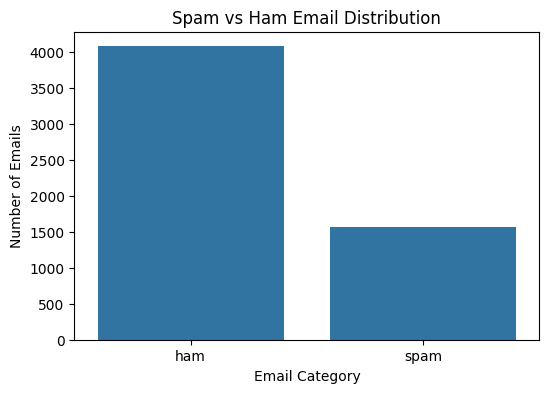

In [9]:
print("Spam/Ham Distribution:")
print(df["Spam/Ham"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Spam/Ham")
plt.title("Spam vs Ham Email Distribution")
plt.xlabel("Email Category")
plt.ylabel("Number of Emails")
plt.show()

### Sample emails from both categories

In [10]:
print("Sample Ham Email:")
display(df[df["Spam/Ham"] == "ham"][["Email_Text", "Spam/Ham"]].head(2))

print("\nSample Spam Email:")
display(df[df["Spam/Ham"] == "spam"][["Email_Text", "Spam/Ham"]].head(2))

Sample Ham Email:


,Email_Text,Spam/Ham
0,me spam is the tool for dissident news since t...,ham
1,escapenumber escapenumber escapenumber penguin...,ham



Sample Spam Email:


,Email_Text,Spam/Ham
4072,attention this is a must for all computer user...,spam
4073,your membership exchange issue escapenumber au...,spam


In [11]:
print("Sample Ham Email:")
display(df[df["Spam/Ham"] == "ham"][["Email_Text", "Spam/Ham"]].head(2))

print("\nSample Spam Email:")
display(df[df["Spam/Ham"] == "spam"][["Email_Text", "Spam/Ham"]].head(2))

Sample Ham Email:


,Email_Text,Spam/Ham
0,me spam is the tool for dissident news since t...,ham
1,escapenumber escapenumber escapenumber penguin...,ham



Sample Spam Email:


,Email_Text,Spam/Ham
4072,attention this is a must for all computer user...,spam
4073,your membership exchange issue escapenumber au...,spam


# Data Cleaning and Preprocessing

The email subject and message are combined into a single text field. Missing message values are handled, and unnecessary HTML tags, URLs, and extra spaces are removed from the email text.

In [12]:
# Create a copy for preprocessing
cleaned_df = df.copy()

# Email_Text pehle se ban chuka hai
print("Missing values in Email_Text:", cleaned_df["Email_Text"].isnull().sum())
print("Shape:", cleaned_df.shape)

Missing values in Email_Text: 0
Shape: (5640, 4)


### Function to clean email text

In [13]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    words = word_tokenize(text)
    words = [lemmatizer.lemmatize(word) for word in words 
             if word not in stop_words and len(word) > 2]
    
    return " ".join(words)

### Apply cleaning

In [14]:
cleaned_df["Processed_Text"] = cleaned_df["Email_Text"].apply(preprocess_text)
print("Preprocessing completed!")

Preprocessing completed!


# NLP Text Preprocessing

The cleaned email text is further processed using basic NLP techniques. The text is converted to lowercase, punctuation and special characters are removed, and common English stopwords are removed.

In [15]:
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    # Convert text to lowercase
    text = text.lower()
    
    # Remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)
    
    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)


# Apply NLP preprocessing
cleaned_df["Processed_Text"] = cleaned_df["Email_Text"].apply(preprocess_text)

print("NLP preprocessing completed!")

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


NLP preprocessing completed!


## Comparision of Original Cleaned Text with Processed Text

In [16]:
comparison = cleaned_df[[
    "Email_Text",
    "Processed_Text",
    "Spam/Ham"
]].head(3)

display(comparison)

,Email_Text,Processed_Text,Spam/Ham
0,me spam is the tool for dissident news since t...,spam tool dissident news since fact unsolicite...,ham
1,escapenumber escapenumber escapenumber penguin...,escapenumber escapenumber escapenumber penguin...,ham
2,on wednesday escapenumber july escapenumber es...,wednesday escapenumber july escapenumber escap...,ham


# Train/Test Split

The preprocessed email data is divided into training and testing sets. Stratified splitting is used to maintain a similar Spam/Ham class distribution in both sets.

In [17]:
# Define features and target

X = cleaned_df["Processed_Text"]
y = cleaned_df["Spam/Ham"]

# Split the dataset into training and testing sets

# Train Test Split
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train_text))
print("Test size:", len(X_test_text))

Train size: 4512
Test size: 1128


In [18]:
# Check class distribution after splitting

print("Training Set Distribution:")
print(y_train.value_counts())

print("\nTesting Set Distribution:")
print(y_test.value_counts())

Training Set Distribution:
Spam/Ham
ham     3258
spam    1254
Name: count, dtype: int64

Testing Set Distribution:
Spam/Ham
ham     814
spam    314
Name: count, dtype: int64


# TF-IDF Vectorization

TF-IDF (Term Frequency-Inverse Document Frequency) is used to convert the preprocessed email text into numerical feature vectors that can be used by machine learning classifiers.

The TF-IDF vectorizer is fitted only on the training data, while the same fitted vectorizer is used to transform the testing data.

In [19]:
# TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.90,
    sublinear_tf=True
)

X_train = tfidf_vectorizer.fit_transform(X_train_text)

X_test = tfidf_vectorizer.transform(X_test_text)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Type of X_train:", type(X_train))

X_train shape: (4512, 15000)
X_test shape: (1128, 15000)
Type of X_train: <class 'scipy.sparse._csr.csr_matrix'>


# Model 1: Naive Bayes Classifier

The Multinomial Naive Bayes classifier is trained on the TF-IDF features to classify emails as Spam or Ham.

In [20]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_test_pred_nb = nb_model.predict(X_test)

## Training Performance

In [21]:
y_train_pred_nb = nb_model.predict(X_train)

print("="*50)
print("Naive Bayes - Training Performance")
print("="*50)

print("Accuracy :", round(accuracy_score(y_train, y_train_pred_nb), 4))
print("Precision:", round(precision_score(y_train, y_train_pred_nb, pos_label="spam"), 4))
print("Recall   :", round(recall_score(y_train, y_train_pred_nb, pos_label="spam"), 4))
print("F1-Score :", round(f1_score(y_train, y_train_pred_nb, pos_label="spam"), 4))

print("\nClassification Report (Train):")
print(classification_report(y_train, y_train_pred_nb, target_names=["Ham", "Spam"]))

Naive Bayes - Training Performance
Accuracy : 0.9767
Precision: 0.9824
Recall   : 0.933
F1-Score : 0.9571

Classification Report (Train):
              precision    recall  f1-score   support

         Ham       0.97      0.99      0.98      3258
        Spam       0.98      0.93      0.96      1254

    accuracy                           0.98      4512
   macro avg       0.98      0.96      0.97      4512
weighted avg       0.98      0.98      0.98      4512



## Testing Performance

In [22]:
y_test_pred_nb  = nb_model.predict(X_test)

print("="*50)
print("Naive Bayes - Testing Performance")
print("="*50)

print("Accuracy :", round(accuracy_score(y_test, y_test_pred_nb), 4))
print("Precision:", round(precision_score(y_test, y_test_pred_nb, pos_label="spam"), 4))
print("Recall   :", round(recall_score(y_test, y_test_pred_nb, pos_label="spam"), 4))
print("F1-Score :", round(f1_score(y_test, y_test_pred_nb, pos_label="spam"), 4))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_nb, target_names=["Ham", "Spam"]))

Naive Bayes - Testing Performance
Accuracy : 0.9707
Precision: 0.9699
Recall   : 0.9236
F1-Score : 0.9462

Classification Report (Test):
              precision    recall  f1-score   support

         Ham       0.97      0.99      0.98       814
        Spam       0.97      0.92      0.95       314

    accuracy                           0.97      1128
   macro avg       0.97      0.96      0.96      1128
weighted avg       0.97      0.97      0.97      1128



# Model 2: Support Vector Machine (SVM)

In [23]:
svm_model = LinearSVC(
    C=1.0,
    class_weight='balanced',
    random_state=42,
    max_iter=2000
)

svm_model.fit(X_train, y_train)

print("SVM Model trained successfully!")

SVM Model trained successfully!


## SVM Training Performance

In [24]:
y_train_pred_svm = svm_model.predict(X_train)

print("="*50)
print("Support Vector Machine - Training Performance")
print("="*50)

print("Accuracy :", round(accuracy_score(y_train, y_train_pred_svm), 4))
print("Precision:", round(precision_score(y_train, y_train_pred_svm, pos_label="spam"), 4))
print("Recall   :", round(recall_score(y_train, y_train_pred_svm, pos_label="spam"), 4))
print("F1-Score :", round(f1_score(y_train, y_train_pred_svm, pos_label="spam"), 4))

print("\nClassification Report (Train):")
print(classification_report(y_train, y_train_pred_svm, target_names=["Ham", "Spam"]))

Support Vector Machine - Training Performance
Accuracy : 0.9998
Precision: 1.0
Recall   : 0.9992
F1-Score : 0.9996

Classification Report (Train):
              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00      3258
        Spam       1.00      1.00      1.00      1254

    accuracy                           1.00      4512
   macro avg       1.00      1.00      1.00      4512
weighted avg       1.00      1.00      1.00      4512



## SVM Testing Performance

In [25]:
y_test_pred_svm  = svm_model.predict(X_test)

print("="*50)
print("Support Vector Machine - Testing Performance")
print("="*50)

print("Accuracy :", round(accuracy_score(y_test, y_test_pred_svm), 4))
print("Precision:", round(precision_score(y_test, y_test_pred_svm, pos_label="spam"), 4))
print("Recall   :", round(recall_score(y_test, y_test_pred_svm, pos_label="spam"), 4))
print("F1-Score :", round(f1_score(y_test, y_test_pred_svm, pos_label="spam"), 4))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_svm, target_names=["Ham", "Spam"]))

Support Vector Machine - Testing Performance
Accuracy : 0.9849
Precision: 0.9685
Recall   : 0.9777
F1-Score : 0.9731

Classification Report (Test):
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       814
        Spam       0.97      0.98      0.97       314

    accuracy                           0.98      1128
   macro avg       0.98      0.98      0.98      1128
weighted avg       0.98      0.98      0.98      1128



# Model Evaluation Function

A common evaluation function is used to calculate Accuracy, Precision, Recall, and F1-Score for the classification models.

In [26]:
def evaluate_model(name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(
        y_true,
        y_pred,
        pos_label="spam",
        zero_division=0
    )
    recall = recall_score(
        y_true,
        y_pred,
        pos_label="spam",
        zero_division=0
    )
    f1 = f1_score(
        y_true,
        y_pred,
        pos_label="spam",
        zero_division=0
    )

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }

# Compare Models

The performance of the Naive Bayes and Support Vector Machine models is compared using Accuracy, Precision, Recall, and F1-Score.

In [27]:
results = []

results.append(
    evaluate_model(
        "Multinomial Naive Bayes",
        y_test,
        y_test_pred_nb
    )
)

results.append(
    evaluate_model(
        "Support Vector Machine",
        y_test,
        y_test_pred_svm
    )
)

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.970745,0.969900,0.923567,0.946166
1,Support Vector Machine,0.984929,0.968454,0.977707,0.973059


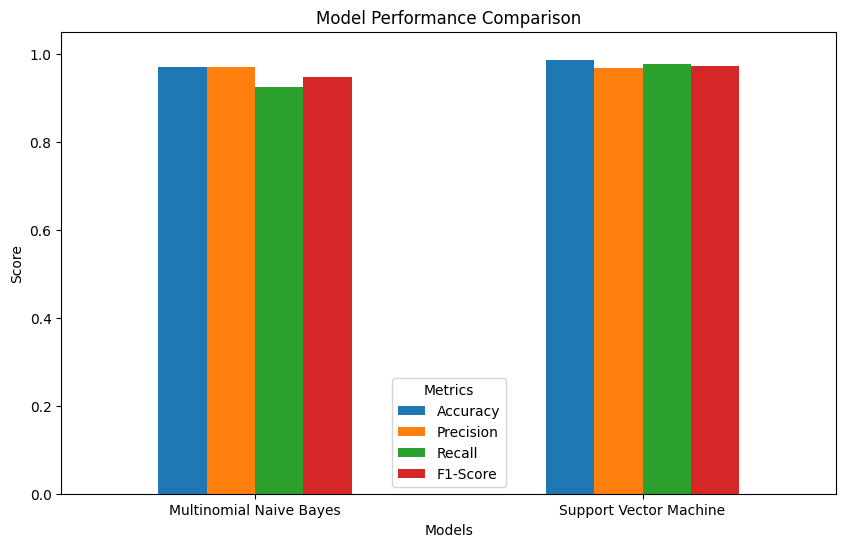

In [28]:
# Model Comparison Graph

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

results_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.show()

# Select Best Model

The best model is selected based on the highest F1-Score because F1-Score provides a balance between Precision and Recall.

In [29]:
best_model_name = results_df.loc[
    results_df["F1-Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Support Vector Machine


# Final Model

The model with the highest F1-Score is selected as the final model for email spam classification.

In [30]:
# Select the best performing model as the final model

if best_model_name == "Multinomial Naive Bayes":
    final_model = nb_model
    final_predictions = y_test_pred_nb
else:
    final_model = svm_model
    final_predictions = y_test_pred_svm

print("Final Model:", best_model_name)

Final Model: Support Vector Machine


## Classification Report

The classification report provides Precision, Recall, F1-Score, and Support for both Spam and Ham email categories.

In [31]:
print("Classification Report")
print("-"* 25)

print(
    classification_report(
        y_test,
        final_predictions,
        target_names=["Ham", "Spam"],
        zero_division=0
    )
)

Classification Report
-------------------------
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       814
        Spam       0.97      0.98      0.97       314

    accuracy                           0.98      1128
   macro avg       0.98      0.98      0.98      1128
weighted avg       0.98      0.98      0.98      1128



In [32]:
final_accuracy = accuracy_score(y_test, final_predictions)
final_f1 = f1_score(
    y_test,
    final_predictions,
    pos_label="spam"
)

print("Final Model Performance")
print("-----------------------")
print(f"Accuracy : {final_accuracy:.4f}")
print(f"F1-Score : {final_f1:.4f}")

Final Model Performance
-----------------------
Accuracy : 0.9849
F1-Score : 0.9731


# Confusion Matrix

The confusion matrix shows the number of correctly and incorrectly classified Ham and Spam emails by the final model.

In [33]:
cm = confusion_matrix(
    y_test,
    final_predictions,
    labels=["ham", "spam"]
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[804  10]
 [  7 307]]


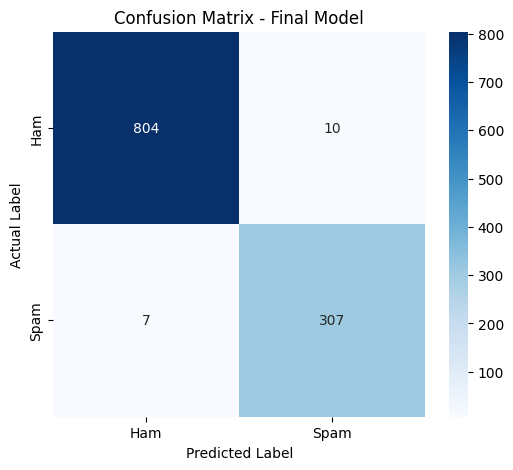

In [34]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix - Final Model")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

## Confusion Matrix Interpretation

The confusion matrix shows the performance of the final model on the test set.

- Most **Ham** emails were correctly classified as Ham.
- Most **Spam** emails were correctly classified as Spam.
- **10 Ham** emails were incorrectly classified as Spam (False Positives).
- **7 Spam** emails were incorrectly classified as Ham (False Negatives).

**Total Misclassified Emails:** 17

Overall, the model performed well with a low number of errors. The slightly higher number of False Positives indicates that the model is a bit more aggressive in predicting emails as spam.

# Error Analysis

Error analysis is performed to identify the emails that were incorrectly classified by the final Support Vector Machine model.

In [35]:
test_indices = X_test_text.index

errors = cleaned_df.loc[test_indices].copy()
errors["Actual"] = y_test.values
errors["Predicted"] = final_predictions

misclassified_emails = errors[errors["Actual"] != errors["Predicted"]]

print("Number of Misclassified Emails:", len(misclassified_emails))

display(misclassified_emails[["Email_Text", "Actual", "Predicted"]].head(10))

Number of Misclassified Emails: 17


,Email_Text,Actual,Predicted
4617,digital video recorder jk escapenumber cost ef...,spam,ham
3009,say goodbye to paper dear globalscape customer...,ham,spam
3985,http www thecliffguy com cliffs htm numerous a...,ham,spam
4637,hey i just wanted to tell you about a great we...,spam,ham
2331,for almost a year we've been working on a new ...,ham,spam
1021,the following domains that are registered as b...,ham,spam
3832,subscription information you have received thi...,ham,spam
5183,mydiscountsoftware inc they have the lowest so...,spam,ham
3796,just curious if subject line capitalization ca...,ham,spam
3170,look at that blimp he must eat six meals a day...,ham,spam


## Class-wise Error Analysis

The misclassified emails are analyzed based on their actual and predicted categories to understand the model's classification errors.

In [36]:
print("Class-wise Error Analysis")
print("-------------------------")

error_summary = pd.crosstab(
    misclassified_emails["Actual"],
    misclassified_emails["Predicted"],
    rownames=["Actual"],
    colnames=["Predicted"]
)

display(error_summary)

Class-wise Error Analysis
-------------------------


Predicted,ham,spam
Actual,,
ham,0,10
spam,7,0


# Prediction Function

A prediction function is created to classify a new email as either Spam or Ham using the trained final model.

In [37]:
def predict_email(email_text):
    # Clean + Preprocess
    cleaned_text = preprocess_text(email_text)
    
    # TF-IDF transform
    email_tfidf = tfidf_vectorizer.transform([cleaned_text])
    
    # Predict
    prediction = final_model.predict(email_tfidf)[0]
    
    return prediction

# Test the Model

In [38]:
sample_emails = [
    # Ham style
    "Hi team, the meeting is scheduled for tomorrow at 10 AM. Please review the attached report.",
    "Please find the updated project timeline. Let me know if you have any questions.",
    
    # Spam style
    "Congratulations! You have won a free iPhone. Click here to claim your prize now.",
    "Urgent! Your account will be suspended. Verify your details immediately by clicking the link.",
    "Make $5000 per week working from home. No experience needed. Limited seats available."
]

for email in sample_emails:
    prediction = predict_email(email)
    print("Email:", email)
    print("Prediction:", prediction.upper())
    print("-" * 98)

Email: Hi team, the meeting is scheduled for tomorrow at 10 AM. Please review the attached report.
Prediction: HAM
--------------------------------------------------------------------------------------------------
Email: Please find the updated project timeline. Let me know if you have any questions.
Prediction: SPAM
--------------------------------------------------------------------------------------------------
Email: Congratulations! You have won a free iPhone. Click here to claim your prize now.
Prediction: SPAM
--------------------------------------------------------------------------------------------------
Email: Urgent! Your account will be suspended. Verify your details immediately by clicking the link.
Prediction: SPAM
--------------------------------------------------------------------------------------------------
Email: Make $5000 per week working from home. No experience needed. Limited seats available.
Prediction: SPAM
---------------------------------------------------

# Save The Model

In [39]:
joblib.dump(final_model, "spam_classifier_model.pkl")
joblib.dump(tfidf_vectorizer, "tfidf_vectorizer.pkl")

print("Model and Vectorizer saved successfully!")

Model and Vectorizer saved successfully!


# Load Model

In [40]:
loaded_model = joblib.load("spam_classifier_model.pkl")
loaded_vectorizer = joblib.load("tfidf_vectorizer.pkl")

print("Model loaded successfully!")

Model loaded successfully!
